In [1]:
# import pandas as pd 
# import xarray as xr 

# # Start date 
# start_date = '2024-08-06'
# end_date = '2024-08-28' 
# Dates = pd.date_range(start_date, end_date, freq='10s')

# hydro = xr.open_dataset('run_hydro/HYDRO_AUGUST6-28.nc')
# # C is temperature (deg C)
# # U is velocity (m/s) (not that important)
# # Kz is vertical diffusivity (m^2/s) 

# # Depth-averaged temperature:
# temp = hydro['C'].mean(dim='z')

# # Temperature averaged over top meter of the water column:
# top_temp = hydro['C'].sel(z=slice(1, 0)).mean(dim='z')



In [1]:
import pandas as pd 
import numpy as np
import os 
import xarray as xr 
import matplotlib.pyplot as plt
import cmocean as cmo 
import pandas as pd 
import numpy as np
import matplotlib.dates as mdates

# Start date 
start_date = '2024-08-06'
end_date = '2024-08-28' 

Dates = pd.date_range(start_date, end_date, freq='10s')

def format_date_ax(ax):
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=4))
    date_format = mdates.DateFormatter('%m/%d %H:%M')
    ax.xaxis.set_major_formatter(date_format)

In [2]:
# Get chl-a and profiler data 

# Chlorophyll-a data
chla = pd.read_csv("/global/homes/s/siennaw/scratch/siennaw/stockton_field_data/forcing_for_model/2024/august6-28/chla_for_adjoint.csv")
chla['time'] = pd.to_datetime(chla['time'])
hab_hf = chla.pg_chla_perML  * 1e-3
hab = hab_hf.rolling(window=10, center=True).mean()

<>:12: SyntaxWarning: invalid escape sequence '\m'
<>:12: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_630805/1463783752.py:12: SyntaxWarning: invalid escape sequence '\m'
  ax.set_ylabel("Chlorophyll-a ($\mu$g/L)")


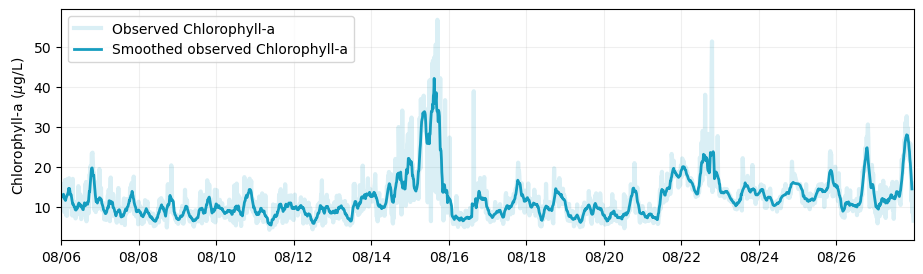

In [3]:
fig = plt.figure(figsize=(11,3))
ax = plt.gca() 
ax.plot(chla.time, hab_hf, color="#0998BC", alpha=0.15, linewidth=3, label='Observed Chlorophyll-a')
ax.plot(chla.time, hab, color="#0998BC", alpha=0.95, linewidth=2, label='Smoothed observed Chlorophyll-a')


ax.set_xlim(chla.time.min(), chla.time.max())
ax.xaxis.set_major_locator(mdates.HourLocator(interval=48))
date_format = mdates.DateFormatter('%m/%d')
ax.xaxis.set_major_formatter(date_format)
ax.grid(alpha=0.2)
ax.set_ylabel("Chlorophyll-a ($\mu$g/L)")
ax.legend(loc='upper left')
fig.savefig("plots/observed_chla_august2024.png", dpi=300)

In [4]:
days = [6, 13] #list(range(6, 28, 1)) 

days_fn = ["august_%02d" % day for day in days]
print(days_fn)

guess = {} 
first = {} 

# get list of files in finished/
read_in = os.listdir('finished2/')
print(read_in)

import re

for file in read_in:
    if file.startswith('forward_1_'):
        match = re.search(r'(\d+)(?=\.nc$)', file)
        day = match.group(1)
        first[day] = xr.open_dataset('finished2/%s' % (file), decode_timedelta=False)
        print("(1) Opened day ", day)
    elif file.startswith('adjoint'):
        pass
    else:
        # print(file)
        match = re.search(r'(\d+)(?=\.nc$)', file)
        day = match.group(1)
        guess[day] = xr.open_dataset('finished2/%s' % (file), decode_timedelta=False)
        print("Opened day ", day)
z = guess[day].z.values

    # Get last two digits 


['august_06', 'august_13']
['forward_400_august_09.nc', 'forward_400_august_17.nc', 'adjoint_1_august_11.nc', 'forward_292_august_06.nc', 'adjoint_1_august_22.nc', 'forward_1_august_24.nc', 'forward_400_august_18.nc', 'forward_400_august_13.nc', 'forward_600_august_22.nc', 'adjoint_1_august_20.nc', 'forward_600_august_20.nc', 'forward_297_august_07.nc', 'forward_1_august_13.nc', 'forward_1_august_22.nc', 'forward_1_august_11.nc', 'forward_400_august_19.nc', 'adjoint_600_august_20.nc', 'adjoint_297_august_15.nc', 'adjoint_1_august_15.nc', 'adjoint_600_august_26.nc', 'adjoint_400_august_18.nc', 'forward_600_august_24.nc', 'adjoint_1_august_21.nc', 'forward_600_august_12.nc', 'adjoint_400_august_16.nc', 'forward_1_august_20.nc', 'adjoint_600_august_23.nc', 'forward_1_august_18.nc', 'adjoint_400_august_19.nc', 'forward_1_august_25.nc', 'adjoint_297_august_25.nc', 'forward_125_august_15.nc', 'adjoint_600_august_21.nc', 'forward_600_august_26.nc', 'forward_400_august_14.nc', 'adjoint_292_aug

In [ ]:

chla2cell_mc =  1e-6/0.36  # ug chl-a/ml --> pg chl-a/ml --> 0.36  pg chl-a/cell Microcystis
chla2cell_diatom = 1e-6/4 # ug chl-a/ml --> pg chl-a/ml --> 4 pg chl-a/cell Diatom
cell2chla_mc = 1/chla2cell_mc
cell2chla_diatom = 1/chla2cell_diatom

def total_algae(dataset):
    total = dataset['algae1'].values.T*cell2chla_mc + dataset['algae2'].values.T*cell2chla_diatom
    return total 


<>:46: SyntaxWarning: invalid escape sequence '\m'
<>:64: SyntaxWarning: invalid escape sequence '\m'
<>:79: SyntaxWarning: invalid escape sequence '\m'
<>:46: SyntaxWarning: invalid escape sequence '\m'
<>:64: SyntaxWarning: invalid escape sequence '\m'
<>:79: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_630805/1651801154.py:46: SyntaxWarning: invalid escape sequence '\m'
  axs[i+8].set_xlabel("Chl-a ($\mu$g/L)")
/tmp/ipykernel_630805/1651801154.py:64: SyntaxWarning: invalid escape sequence '\m'
  ax1.set_ylabel("Chl-a ($\mu$g/L)")
/tmp/ipykernel_630805/1651801154.py:79: SyntaxWarning: invalid escape sequence '\m'
  axs[i+12].set_xlabel("Chl-a ($\mu$g/L)")


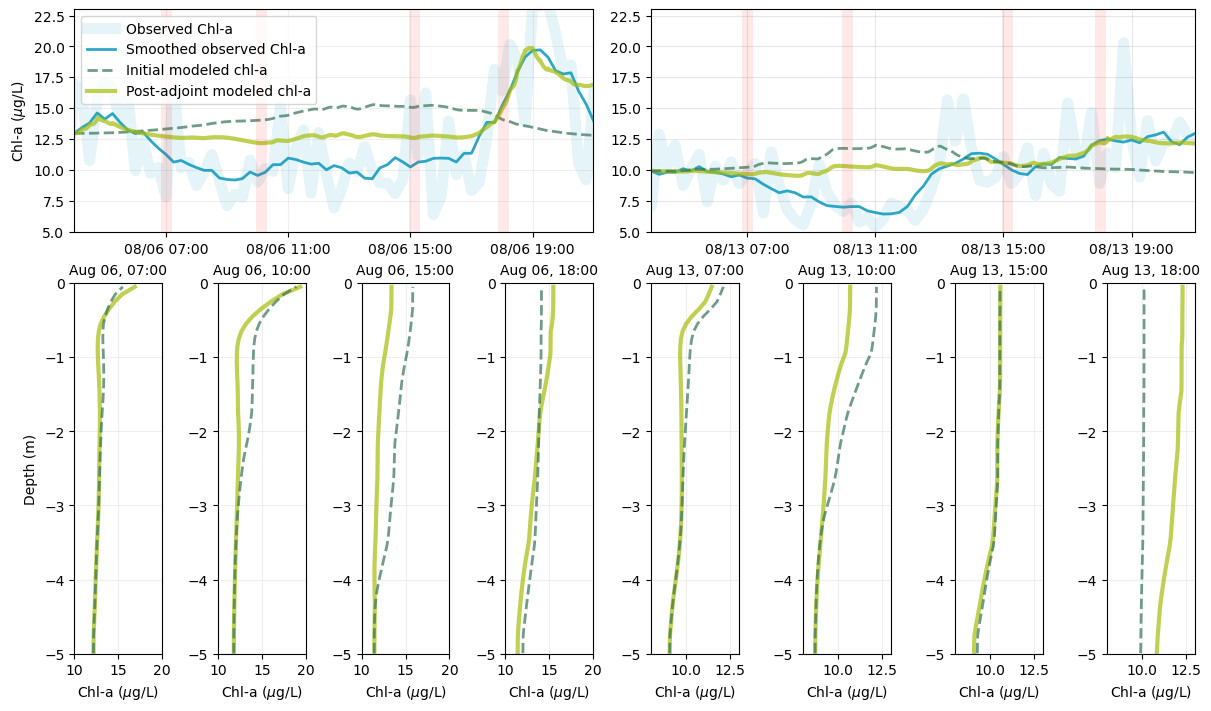

In [68]:
# Make big composite plot 
fig, axs = plt.subplots(nrows=2, ncols=8, figsize=(12, 7), height_ratios=[0.6, 1], sharex=False, constrained_layout=True)
axs = axs.flatten()


gs = axs[0].get_gridspec()
# remove the underlying Axes
for ax in axs[0:8]:
    ax.remove()
ax1 = fig.add_subplot(gs[0:4])
ax2= fig.add_subplot(gs[4:8])

time_r = [1080, 2200, 4000, 5050]


for ax in [ax1, ax2]:
    ax.plot(chla.time, hab_hf, color="#0998BC", alpha=0.1, linewidth=8, label='Observed Chl-a')
    ax.plot(chla.time, hab, color="#0998BC", alpha=0.85, linewidth=2, label='Smoothed observed Chl-a')
    format_date_ax(ax)
    ax.set_ylim(5,23)
    ax.grid(alpha=0.3)

# --------------------------------------------------------
# DAY (1) 
day = 6 
ds = guess["%02d" % day].isel(z=slice(48,52)).mean(dim='z')
dsf = first["%02d" % day].isel(z=slice(48,52)).mean(dim='z')
time = Dates[ds.t.values]
ax1.plot(time, total_algae(dsf)*1e-3, '--',  color="#347355", linewidth=2, alpha=0.7, label="Initial modeled chl-a")
ax1.plot(time, total_algae(ds)*1e-3, '-',  color='#A6BC09', linewidth=3, alpha=0.7, label="Post-adjoint modeled chl-a")
ax1.set_xlim(time[0], time[-10])

ds = guess["%02d" % day]
dsf = first["%02d" % day]

time = Dates[ds.t.values]
axs[8].set_ylabel("Depth (m)")

for i,t in enumerate(time_r):
    axs[i+8].plot(total_algae(ds.isel(t=t))*1e-3, -z, '-',  color='#A6BC09', linewidth=3, alpha=0.7, label="Post-adjoint modeled chl-a")
    axs[i+8].plot(total_algae(dsf.isel(t=t))*1e-3, -z, '--',  color="#347355", linewidth=2, alpha=0.7, label="Initial modeled chl-a")
    axs[i+8].grid(alpha=0.2)
    axs[i+8].set_xlim(10,20)
    axs[i+8].set_ylim(-5,0)
    axs[i+8].set_title(time[t].strftime("%b %d, %H:00"), fontsize=10)
    axs[i+8].set_xlabel("Chl-a ($\mu$g/L)") 

    ax1.vlines(time[t],0,40, color='r', linewidth=8, alpha=0.09)

# --------------------------------------------------------
# DAY (2)
day = 13
ds = guess["%02d" % day].isel(z=slice(48,52)).mean(dim='z')
dsf = first["%02d" % day].isel(z=slice(48,52)).mean(dim='z')
time = Dates[ds.t.values]
ax2.plot(time, total_algae(ds)*1e-3, '-',  color='#A6BC09', linewidth=3, alpha=0.7, label="Post-adjoint modeled chl-a")
ax2.plot(time, total_algae(dsf)*1e-3, '--',  color="#347355", linewidth=2, alpha=0.7, label="Initial modeled chl-a")
ax2.set_xlim(time[0], time[-10])



ax1.grid(alpha=0.2)
ax1.legend(fontsize=10, loc='upper left')
ax1.set_ylabel("Chl-a ($\mu$g/L)")


ds = guess["%02d" % day]
dsf = first["%02d" % day]

time = Dates[ds.t.values]
for i,t in enumerate(time_r):
    ax2.vlines(time[t],0,40, color='r', linewidth=8, alpha=0.09)
    axs[i+12].plot(total_algae(ds.isel(t=t))*1e-3, -z, '-',  color='#A6BC09', linewidth=3, alpha=0.7, label="Post-adjoint modeled chl-a")
    axs[i+12].plot(total_algae(dsf.isel(t=t))*1e-3, -z, '--',  color="#347355", linewidth=2, alpha=0.7, label="Initial modeled chl-a")
    axs[i+12].set_xlim(8,13)
    axs[i+12].set_ylim(-5,0)
    axs[i+12].grid(alpha=0.2)
    axs[i+12].set_title(time[t].strftime("%b %d, %H:00"), fontsize=10)
    axs[i+12].set_xlabel("Chl-a ($\mu$g/L)") 


fig.savefig("full_validation.png")


In [7]:
day = 13 

for day in range(6, 27):
    print(day)
    fig, ax = plt.subplots(1, 1, figsize=(10, 3), sharex=True)

    ax.plot(chla.time, hab_hf, color="#0998BC", alpha=0.15, linewidth=3, label='Observed Chlorophyll-a (ug/L)')
    ax.plot(chla.time, hab, color="#0998BC", alpha=0.85, linewidth=2, label='Smoothed observed Chlorophyll-a (ug/L)')

    for i in range(48,52): 
        ds = guess["%02d" % day].isel(z=i)
        time = Dates[ds.t.values]

        # End 
        total = ds['algae1'].values.T*cell2chla_mc + ds['algae2'].values.T*cell2chla_diatom
        ax.plot(time, total*1e-3, '-',  color='#A6BC09', linewidth=1, alpha=0.7)

    ax.plot([], [], '-', label=r'Modeled (diatoms + $Microcystis$)', color='#A6BC09', linewidth=1, alpha=0.7)

    ax.set_xlim(time[0], time[-1])
    ax.set_ylim(3, 25)
    format_date_ax(ax)
    ax.grid(alpha=0.3)
    ax.set_ylabel("Chlorophyll-a (ug/L)")
    ax.legend()
    fig.savefig("plots/validation_chla_august%d.png" % day, dpi=300, bbox_inches='tight')
    print("Saved figure for day ", day)
    plt.close()


6
Saved figure for day  6
7
Saved figure for day  7
8
Saved figure for day  8
9
Saved figure for day  9
10
Saved figure for day  10
11
Saved figure for day  11
12
Saved figure for day  12
13
Saved figure for day  13
14
Saved figure for day  14
15
Saved figure for day  15
16
Saved figure for day  16
17
Saved figure for day  17
18
Saved figure for day  18
19
Saved figure for day  19
20
Saved figure for day  20
21
Saved figure for day  21
22
Saved figure for day  22
23
Saved figure for day  23
24
Saved figure for day  24
25
Saved figure for day  25
26
Saved figure for day  26


In [8]:

# Read in profiler data 
profiles = pd.read_csv("/global/homes/s/siennaw/scratch/siennaw/stockton_field_data/forcing_for_model/2024/august6-16/vertical_profiles_for_adjoint_pgML.csv")
profz = profiles['z'].values

prof_times = profiles.columns
prof_times = prof_times[:-1]

nprofiles = len(prof_times)

In [9]:
# # August 6th 

# day = 6

# fig, axs = plt.subplots(nrows=1, ncols=6, figsize=(12, 4), sharex=True, sharey=True)
# for i in range(0, 6):
    
#     time = int(prof_times[i])  # Skip the first column which is 'z'

#     total = guess["%02d" % day]["algae1"].values[time,:]*cell2chla_mc + guess["%02d" % day]["algae2"].values[time,:]*cell2chla_diatom
#     axs[i].plot(total*1e-3, -z, color='#A6BC09', linewidth=4, label='Total algae')
    
#     axs[i].plot(profiles[prof_times[i]]*1e-3, -profz, '--', color='#0998BC', markersize=3, label='Observed algae')

#     axs[i].grid(alpha=0.3)
#     # axs[i].set_title(dates[time].strftime('%m/%d %H:%M'))
#     # print(dates[i])
#     axs[i].set_xlabel("ug/L chl-a")
#     axs[i].set_xlim(0, 25)
#     axs[0].legend()


In [10]:

fn = "/global/homes/s/siennaw/scratch/siennaw/stockton_field_data/profiler/"

metadata = pd.read_csv(fn +  "Profiles_metadata.csv")
metadata = metadata.loc[metadata['site'] == 'WEB']
times = pd.to_datetime(metadata['timestamp'])
metadata['time'] = times 
metadata.sort_values(by='time', inplace=True)


pids = metadata['profile_id'].values
pdates = [t.date() for t in metadata['time']]
metadata['date'] = pdates
days1 = np.unique(pdates)
days2= [day.day for day in days1]
ndays = len(days1)


data = pd.read_csv( fn + "T3_TurbulenceHABs_binned_profiles.csv")

param2name = {'ln_par_sat_log':'ln PAR', 'modeled_par_sat_log':'modeled ln PAR',
              'chl_ugl':'chl-a (ug/L)', 'turb_ntu':'Turbidity (NTU)', 'pH':'pH', 'do_mgl':'DO (mg/L)', 'temp_degc':'Temperature (deg C)'}

param = 'chl_ugl'


There are 5 hours with data on day  2024-08-06


/tmp/ipykernel_2315360/2980905072.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  daily_metadata['hour'] = hours
/tmp/ipykernel_2315360/2980905072.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  daily_metadata['hour'] = hours


There are 8 hours with data on day  2024-08-13


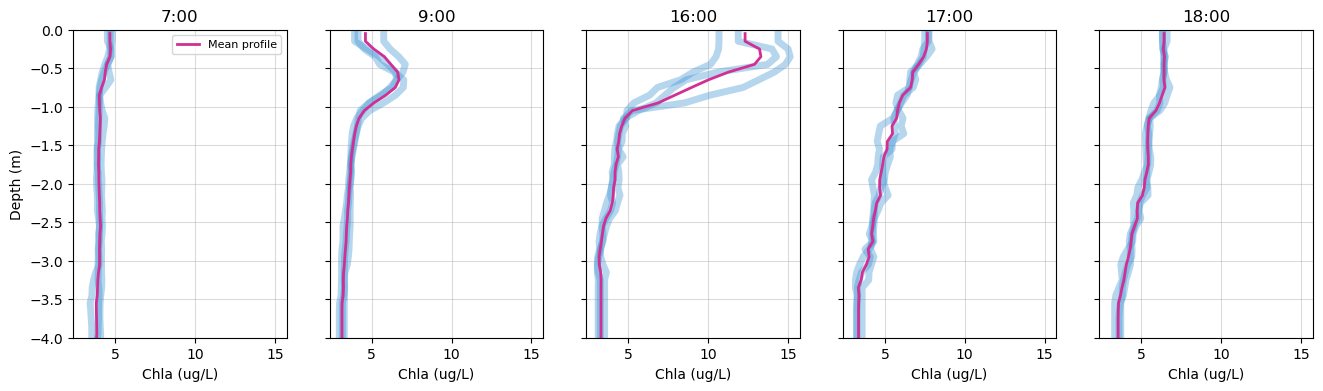

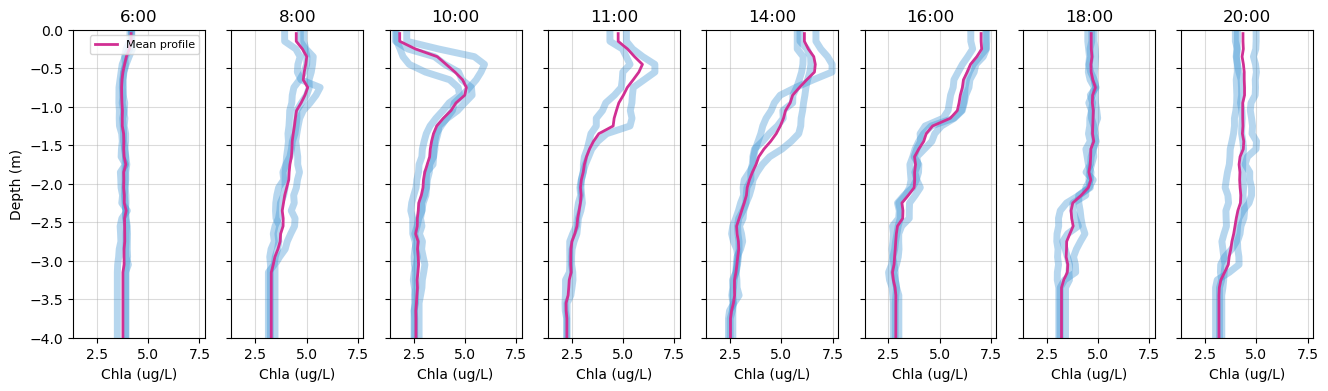

In [11]:
# average profiles close to each other
N =len(z)

start_time = pd.to_datetime("2024-08-06 00:00:00") # Start of full simulation 

for d, day in zip(days2[0:-1], days1[0:-1]): 
    daily_metadata = metadata.loc[metadata['date'] == day]
    hours = [t.hour for t in daily_metadata['time']]
    daily_metadata['hour'] = hours
    
    hours = np.unique(hours)
    hours = hours[hours != 12]  # remove midnight
    nhours = len(hours)
    print("There are %d hours with data on day " % nhours, day)

    fig, axs  = plt.subplots(nrows=1, ncols=nhours, figsize=(16, 4), sharex=True, sharey=True)
    title="Vertical profiles on %s Weber Pt" % day

    model_chla = guess["%02d" % d]["algae1"]*cell2chla_mc + guess["%02d" % d]["algae2"]*cell2chla_diatom
    for ih, hour in enumerate(hours):

        profile_at_hour = daily_metadata.loc[daily_metadata['hour'] == hour]
        PIDs = np.unique(profile_at_hour['profile_id'].values)
        cast_at_hour = np.zeros((N,))
        
        # ax2 = axs[ih].twiny()
        for pid in PIDs:
            prof_data = data.loc[data['profile_id'] == pid]

            # join metadata on profile_id
            full_data = prof_data.merge(daily_metadata, on='profile_id', how='left')
            time_of_cast = pd.to_datetime(full_data['time'].values[0])

            t = time_of_cast - start_time
            t_model = t.total_seconds() // 10

            up_cast = prof_data.loc[prof_data['cast_status'] == 'up']
            down_cast = prof_data.loc[prof_data['cast_status'] == 'down']

            cast = down_cast.loc[down_cast['measurement'] == param]
            cast = cast[['value' , 'depth_m']].reset_index(drop=True)

            cast.index = cast.depth_m
            cast = cast.reindex(z, method='nearest')
            cast = cast.interpolate(method='polynomial', order=1)

            cast_at_hour += cast['value'].values
            axs[ih].plot(cast['value'], -cast.index, '-', linewidth=5, alpha=0.35, color="#2f8cd1")


        # model_chla0 = model_chla.sel(t=t_model , method='nearest')
        # ax2.plot(model_chla0*1e-3, -z, '-', color= "#2fd13f", linewidth=2)

            # cast = up_cast.loc[up_cast['measurement'] == param]
            # axs[ih].plot(cast['value'], -cast['depth_m'], linewidth=3,  label='up cast', color="#e67388")

        axs[ih].set_xlabel(r"Chla (ug/L)")
        axs[ih].set_title("%d:00" % (hour))
        axs[ih].grid(alpha=0.45, which='both')
        # ax2.set_xlim(7, 30)
        # ax2.tick_params(axis='x', colors='#2fd13f')
        cast_at_hour = cast_at_hour / len(PIDs)
        if ih==0:
            axs[ih].plot(cast_at_hour, -z, '-', color="#d12f93", linewidth=2, label="Mean profile")
            # axs[ih].plot([], [], '-',  color= "#2fd13f", linewidth=2, label="Modeled chl-a")
        else:
            axs[ih].plot(cast_at_hour, -z, '-', color="#d12f93", linewidth=2)
        # if d==6:
        #     ax2.set_xlim(7, 30)
        # elif d==13:
        #     ax2.set_xlim(8, 14)
    axs[0].set_ylabel('Depth (m)')
    axs[0].legend(loc='upper right', fontsize=8)
    axs[0].set_ylim(-4,0)
    fig.savefig("plots/profiles_nomodel_august%d.png" % d, dpi=400)
